## FashionMNIST 분류 모델

GPU 설정

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


### 데이터 로드

In [2]:
tranform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])  

In [3]:
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=tranform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=tranform)

In [4]:
from torch.utils.data import Dataset, DataLoader
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)                                    
test_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)                                    

In [5]:
images, labels = next(iter(train_loader))
images.shape, labels.shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

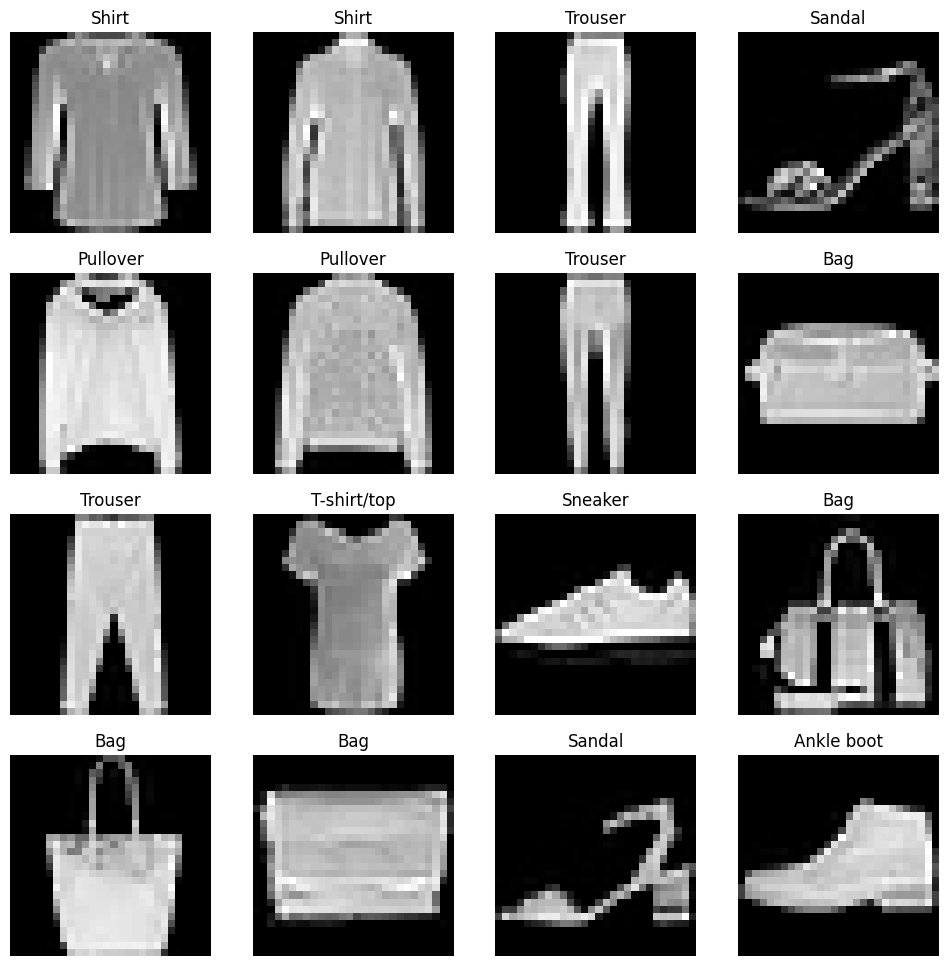

In [6]:
import matplotlib.pyplot as plt

labels_map = {
  0: "T-shirt/top",
  1: "Trouser",
  2: "Pullover",
  3: "Dress",
  4: "Coat",
  5: "Sandal",
  6: "Shirt",
  7: "Sneaker",
  8: "Bag",
  9: "Ankle boot",
}

figure = plt.figure(figsize=(12, 12))
cols, rows = 4, 4
for i in range(1, cols * rows + 1):
    image = images[i].squeeze()                 # squeeze() 채널 차원 제거
    label_idx = labels[i].item()                # item() 텐서의 값을 스칼라로 변환
    label = labels_map[label_idx]               # 레이블 매핑

    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(image.squeeze(), cmap="gray")

### 모델 정의 및 파라미터

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 3)       # 1채널 입력, 6채널 출력, 3x3 커널
        self.conv2 = nn.Conv2d(6, 16, 3)      # 6채널 입력, 16채널 출력, 3x3 커널
        self.fc1 = nn.Linear(16*5*5, 120)     # 16*5*5 입력, 120 출력
        self.fc2 = nn.Linear(120, 84)         # 120 입력, 84 출력
        self.fc3 = nn.Linear(84, 10)          # 84 입력, 10 출력

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)        
        return x
    
    def num_flat_features(self, x):
        size = x.size()[1:]
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

net = NeuralNet()
print(net)            

NeuralNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [8]:
paarams = list(net.parameters())    # 모델의 파라미터를 리스트로 반환
print(len(paarams))                 # 10개의 파라미터 텐서가 반환
print(paarams[0].size())            # conv1의 가중치

10
torch.Size([6, 1, 3, 3])


In [9]:
input = torch.randn(1 ,1, 28, 28)
out = net(input)
print(out)

tensor([[-0.0316, -0.1421,  0.1115,  0.0501,  0.0936, -0.1580,  0.0656,  0.0266,
         -0.0543, -0.0611]], grad_fn=<AddmmBackward0>)


### 손실함수와 옵티마이저

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

### 모델 학습

배치수 확인

In [11]:
total_batch = len(train_loader)
print('total_batch:', total_batch)

total_batch: 469


In [12]:
for epoch in range(10):
  running_loss = 0.0                              # loss를 저장하기 위한 변수

  for i, data in enumerate(train_loader, 0):
    inputs, labels = data                         # 데이터를 가져옴
    
    optimizer.zero_grad()                         # gradient를 0으로 초기화

    outputs = net(inputs)                         # 모델에 입력을 넣어 출력을 계산
    loss = criterion(outputs, labels)             # outputs와 labels의 차이를 계산
    loss.backward()                               # 역전파
    optimizer.step()                              # 최적화

    running_loss += loss.item()                   # loss를 running_loss에 더함

    if i % 100 == 99:           
      print(f'Epoch : {epoch + 1}, iter : {i + 1}, Loss : {running_loss / 2000}')
      running_loss = 0.0                          # running_loss를 0으로 초기화

Epoch : 1, iter : 100, Loss : 0.11491009974479675
Epoch : 1, iter : 200, Loss : 0.11426152956485748
Epoch : 1, iter : 300, Loss : 0.11326457035541534
Epoch : 1, iter : 400, Loss : 0.11118916201591492
Epoch : 2, iter : 100, Loss : 0.09357456564903259
Epoch : 2, iter : 200, Loss : 0.06656897622346879
Epoch : 2, iter : 300, Loss : 0.05095155310630799
Epoch : 2, iter : 400, Loss : 0.044591185182332994
Epoch : 3, iter : 100, Loss : 0.03883876731991768
Epoch : 3, iter : 200, Loss : 0.03667014756798744
Epoch : 3, iter : 300, Loss : 0.03479370886087418
Epoch : 3, iter : 400, Loss : 0.033065555572509765
Epoch : 4, iter : 100, Loss : 0.03198828057944775
Epoch : 4, iter : 200, Loss : 0.03222359852492809
Epoch : 4, iter : 300, Loss : 0.03124090085923672
Epoch : 4, iter : 400, Loss : 0.030405661448836326
Epoch : 5, iter : 100, Loss : 0.02997817985713482
Epoch : 5, iter : 200, Loss : 0.029761741146445274
Epoch : 5, iter : 300, Loss : 0.02809576679766178
Epoch : 5, iter : 400, Loss : 0.02961711747944

### 모델의 저장 및 로드

- `torch.save`: `net.state_dict()`를 저장
- `torch.load`: `load_state_dict`로 모델을 로드

In [13]:
PATH = './fashion_net.pth'
torch.save(net.state_dict(), PATH)           # 모델을 저장

In [14]:
net = NeuralNet()                           # 모델을 불러옴
net.load_state_dict(torch.load(PATH))       # 모델의 가중치를 불러옴

<All keys matched successfully>

In [15]:
net.parameters

<bound method Module.parameters of NeuralNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)>

### 모델 테스트

In [22]:
import numpy as np

def imshow(image):
  image = image / 2 + 0.5
  npimg = image.numpy()

  fig = plt.figure(figsize = (16, 8))
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()

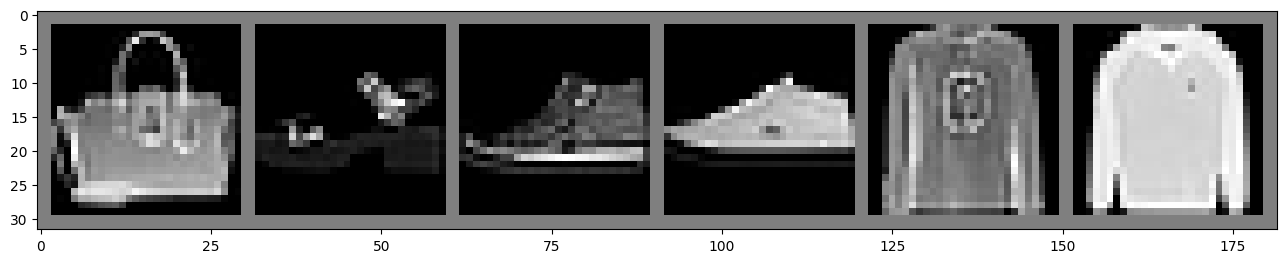

In [23]:
import torchvision

dataiter = iter(test_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:6]))

In [26]:
output = net(images)

_, predicted = torch.max(output, 1)   # 가장 큰 값의 인덱스를 반환
print(predicted[:6])                  

for i in predicted[:6]:
  print(labels_map[i.item()])         # 예측한 레이블 출력

tensor([8, 5, 7, 7, 2, 2])
Bag
Sandal
Sneaker
Sneaker
Pullover
Pullover


In [27]:
correct = 0
total = 0

with torch.no_grad():
  for data in test_loader:
    images, labels = data                             # 데이터를 가져옴
    outputs = net(images)                             # 모델에 입력을 넣어 출력을 계산
    _, predicted = torch.max(outputs.data, 1)         # 가장 큰 값의 인덱스를 반환
    total += labels.size(0)                           # 전체 개수
    correct += (predicted == labels).sum().item()     # 맞은 개수

print(f'Accuracy of the test images: {100 * correct / total} %')

Accuracy of the network on the 10000 test images: 83.925 %
